# Clustering Urban Mobility Patterns Using Bike-Sharing Data
**Course assignment notebook — built step by step**

This notebook follows the assignment structure exactly:
1. Data Preparation & Feature Engineering
2. Clustering Methods (K-Means, AGNES, DBSCAN)
3. Evaluation & Comparison
4. Cluster Interpretation & Validation
5. Theoretical Questions (answered in the report, referenced here)


## 0. Setup
Import libraries and set a fixed random seed for reproducibility.

In [1]:
# Libraries will be added here as we need them, one step at a time.
import numpy as np
import pandas as pd

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## Part 1: Data Preparation and Feature Engineering

### 1.1 Inspect and Clean the Data
- Load `hour.csv`
- Check missing values, invalid values, duplicates
- Convert `dteday` to datetime
- Verify each date has a reasonable number of hourly observations
- Identify and handle unusual/incomplete days

In [2]:
df = pd.read_csv("data/hour.csv") 

df['dteday'] = pd.to_datetime(df['dteday'])
print("Shape of the dataset:", df.shape)

# Check for missing values
total_missing = df.isnull().sum().sum()
print(f"\nTotal missing values in the dataset: {total_missing}")

# Check for duplicate rows, and duplicate (date, hour) pairs
duplicated_rows = df.duplicated().sum()
print(f"\nNumber of duplicated rows in the dataset: {duplicated_rows}")

duplicate_date_hour = df.duplicated(subset=['dteday', 'hr']).sum()
print(f"Duplicate (date, hour) pairs: {duplicate_date_hour}\n")

for col in ['temp', 'atemp', 'hum', 'windspeed']:
    print(f"{col}: min={df[col].min()}, max={df[col].max()}")

hourly_counts = df.groupby('dteday').size()
print(f"\nHourly counts: {hourly_counts.shape[0]}")
print(f"Days with all 24 hours present: {(hourly_counts == 24).sum()}")
print(f"Days missing at least 1 hour: {(hourly_counts < 24).sum()}")

# Decide a cutoff for "usable" days
MIN_HOURS_PER_DAY = 22
complete_days = hourly_counts[hourly_counts >= MIN_HOURS_PER_DAY].index
incomplete_days = hourly_counts[hourly_counts < MIN_HOURS_PER_DAY]

print(f"\nDays kept (>= {MIN_HOURS_PER_DAY} hours): {len(complete_days)}")
print(f"Days dropped (< {MIN_HOURS_PER_DAY} hours): {len(incomplete_days)}")
print(incomplete_days.sort_values())

# clean data
df_clean = df[df['dteday'].isin(complete_days)].copy()
print("\nRows remaining after filtering:", df_clean.shape[0])

Shape of the dataset: (17379, 17)

Total missing values in the dataset: 0

Number of duplicated rows in the dataset: 0
Duplicate (date, hour) pairs: 0

temp: min=0.02, max=1.0
atemp: min=0.0, max=1.0
hum: min=0.0, max=1.0
windspeed: min=0.0, max=0.8507

Hourly counts: 731
Days with all 24 hours present: 655
Days missing at least 1 hour: 76

Days kept (>= 22 hours): 723
Days dropped (< 22 hours): 8
dteday
2012-10-29     1
2011-01-27     8
2012-10-30    11
2011-01-18    12
2011-01-26    16
2011-08-28    17
2011-02-22    18
2011-08-27    18
dtype: int64

Rows remaining after filtering: 17278


### 1.2 Generate Daily Mobility Features
Aggregate hourly records into one row per day.

In [3]:
# Aggregate the cleaned hourly records into one row per day 
daily_agg = df_clean.groupby('dteday').agg(
    total_rentals=('cnt', 'sum'),
    avg_hourly_rentals=('cnt', 'mean'),
    max_hourly_rentals=('cnt', 'max'),
    std_hourly_rentals=('cnt', 'std'),
    total_casual=('casual', 'sum'),
    total_registered=('registered', 'sum'),
    avg_temp=('temp', 'mean'),
    avg_atemp=('atemp', 'mean'),
    avg_hum=('hum', 'mean'),
    avg_windspeed=('windspeed', 'mean'),
    season=('season', 'first'),
    yr=('yr', 'first'),
    mnth=('mnth', 'first'),
    holiday=('holiday', 'first'),
    weekday=('weekday', 'first'),
    workingday=('workingday', 'first'),
    weathersit=('weathersit', lambda x: x.mode()[0])  
).reset_index()

# Filter Morning and evening peak hours 
morning_sum = df_clean[df_clean['hr'].between(6, 9)].groupby('dteday')['cnt'].sum().rename('morning_rentals')
evening_sum = df_clean[df_clean['hr'].between(16, 19)].groupby('dteday')['cnt'].sum().rename('evening_rentals')

# Merge to daily_agg
daily_agg = daily_agg.merge(morning_sum, on='dteday', how='left').merge(evening_sum, on='dteday', how='left')
daily_agg[['morning_rentals', 'evening_rentals']] = daily_agg[['morning_rentals', 'evening_rentals']].fillna(0)

daily_agg['morning_peak_share'] = daily_agg['morning_rentals'] / daily_agg['total_rentals']
daily_agg['evening_peak_share'] = daily_agg['evening_rentals'] / daily_agg['total_rentals']
daily_agg['offpeak_share'] = 1 - daily_agg['morning_peak_share'] - daily_agg['evening_peak_share']

# Casual and registered user proportions 
daily_agg['casual_prop'] = daily_agg['total_casual'] / daily_agg['total_rentals']
daily_agg['registered_prop'] = daily_agg['total_registered'] / daily_agg['total_rentals']

print("\nDaily aggregated dataset shape:", daily_agg.shape)
daily_agg.head()


Daily aggregated dataset shape: (723, 25)


,dteday,total_rentals,avg_hourly_rentals,max_hourly_rentals,std_hourly_rentals,total_casual,total_registered,avg_temp,avg_atemp,avg_hum,...,weekday,workingday,weathersit,morning_rentals,evening_rentals,morning_peak_share,evening_peak_share,offpeak_share,casual_prop,registered_prop
0,2011-01-01,985,41.041667,110,34.292196,331,654,0.344167,0.363625,0.805833,...,6,0,1,27,232,0.027411,0.235533,0.737056,0.336041,0.663959
1,2011-01-02,801,34.826087,93,29.785067,131,670,0.363478,0.353739,0.696087,...,0,0,2,31,224,0.038702,0.279650,0.681648,0.163546,0.836454
2,2011-01-03,1349,61.318182,157,48.792453,120,1229,0.196364,0.189405,0.437273,...,1,1,1,336,500,0.249073,0.370645,0.380282,0.088955,0.911045
3,2011-01-04,1562,67.913043,212,59.889985,108,1454,0.200000,0.212122,0.590435,...,2,1,1,409,589,0.261844,0.377081,0.361076,0.069142,0.930858
4,2011-01-05,1600,69.565217,195,58.427753,82,1518,0.226957,0.229270,0.436957,...,3,1,1,431,580,0.269375,0.362500,0.368125,0.051250,0.948750


### 1.3 Prepare the Clustering Data
- Check distributions / skew
- Handle correlated or redundant features
- Standardize features
- Justify any removed features

In [4]:
from sklearn.preprocessing import StandardScaler

candidate_features = ['total_rentals', 'avg_hourly_rentals', 'max_hourly_rentals', 'std_hourly_rentals',
                      'morning_peak_share', 'evening_peak_share', 'offpeak_share',
                      'casual_prop', 'registered_prop', 'avg_temp', 'avg_atemp', 'avg_hum', 'avg_windspeed']

# Check skewness of candidate features
print("Skewness of each candidate feature:")
print(daily_agg[candidate_features].skew().sort_values(ascending=False))

# Look for redundant / highly correlated features
corr_matrix = daily_agg[candidate_features].corr()
print("\nPairs with |correlation| > 0.85:")
for i in range(len(candidate_features)):
    for j in range(i + 1, len(candidate_features)):
        c = corr_matrix.iloc[i, j]
        if abs(c) > 0.85:
            print(f"{candidate_features[i]} <-> {candidate_features[j]}: {c:.3f}")

# Handle correlated or redundant features
# 1. total_rentals is a constant multiple of avg_hourly_rentals (corr = 1.00)
#    since almost every day has ~24 hours -> drop total_rentals
# 2. offpeak_share is mathematically determined by the other two shares
#    (offpeak = 1 - morning - evening) - it carries zero new information,
#    so drop it rather than let it double-count morning/evening.
# 3. registered_prop is the exact complement of casual_prop (registered = 1 - casual, 
#    corr = -1.00) -> drop registered_prop
# 4. avg_atemp correlates 0.99 with avg_temp. Keeping both would let "temperature" count
#    almost twice as much as any other feature ->  drop avg_atemp, keep the more standard avg_temp.
# 5. max_hourly_rentals and std_hourly_rentals both correlate > 0.92 with avg_hourly_rentals and with each other. 
#    All three primarily captured overall rental *volume* rather than distinct behaviour.
#    -> cv_hourly_rentals (coefficient of variation) isolates how "spiky vs. flat" a day is independent of how busy it was 
daily_agg['cv_hourly_rentals'] = daily_agg['std_hourly_rentals'] / daily_agg['avg_hourly_rentals']
print("\ncv_hourly_rentals corr with avg_hourly_rentals:",
      round(daily_agg['cv_hourly_rentals'].corr(daily_agg['avg_hourly_rentals']), 3))

# Transformation to reduce skew uding square root
print("\ncasual_prop skew :",
      round(daily_agg['casual_prop'].skew(), 3), "->",
      round(daily_agg['casual_prop'].apply(lambda x: x ** 0.5).skew(), 3))
daily_agg['casual_prop_sqrt'] = daily_agg['casual_prop'] ** 0.5

print("avg_windspeed skew :",
      round(daily_agg['avg_windspeed'].skew(), 3), "->",
      round(daily_agg['avg_windspeed'].apply(lambda x: x ** 0.5).skew(), 3))
daily_agg['avg_windspeed_sqrt'] = daily_agg['avg_windspeed'] ** 0.5

# Final featureS for clustering
final_features = ['avg_hourly_rentals', 'cv_hourly_rentals', 'morning_peak_share', 'evening_peak_share',
                  'casual_prop_sqrt', 'avg_temp', 'avg_hum', 'avg_windspeed_sqrt']

# Check skewness of final features
final_corr = daily_agg[final_features].corr()
remaining_high_corr = []
for i in range(len(final_features)):
    for j in range(i + 1, len(final_features)):
        c = final_corr.iloc[i, j]
        if abs(c) > 0.85:
            remaining_high_corr.append((final_features[i], final_features[j], round(c, 3)))
print("\nRemaining |corr| > 0.85 in final feature set:", remaining_high_corr or "None")

# Standardize the final features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(daily_agg[final_features])
X_scaled = pd.DataFrame(X_scaled, columns=final_features, index=daily_agg.index)
X_scaled.head()

print("\nScaled feature means:", X_scaled.mean().round(3))
print("\nScaled feature std devs:", X_scaled.std().round(3))






Skewness of each candidate feature:
casual_prop           0.941105
avg_windspeed         0.682048
offpeak_share         0.680854
max_hourly_rentals    0.024638
avg_hourly_rentals   -0.024681
std_hourly_rentals   -0.025658
total_rentals        -0.030869
avg_temp             -0.057926
avg_hum              -0.068855
avg_atemp            -0.135142
morning_peak_share   -0.261408
evening_peak_share   -0.653484
registered_prop      -0.941105
dtype: float64

Pairs with |correlation| > 0.85:
total_rentals <-> avg_hourly_rentals: 1.000
total_rentals <-> max_hourly_rentals: 0.928
total_rentals <-> std_hourly_rentals: 0.975
avg_hourly_rentals <-> max_hourly_rentals: 0.928
avg_hourly_rentals <-> std_hourly_rentals: 0.975
max_hourly_rentals <-> std_hourly_rentals: 0.969
morning_peak_share <-> offpeak_share: -0.908
casual_prop <-> registered_prop: -1.000
avg_temp <-> avg_atemp: 0.992

cv_hourly_rentals corr with avg_hourly_rentals: -0.223

casual_prop skew : 0.941 -> 0.375
avg_windspeed skew : 0.682 

### 1.4 Exploratory Visualisation
- Histograms / boxplots
- Correlation heatmap
- Daily rental pattern plots
- PCA 2D visualisation

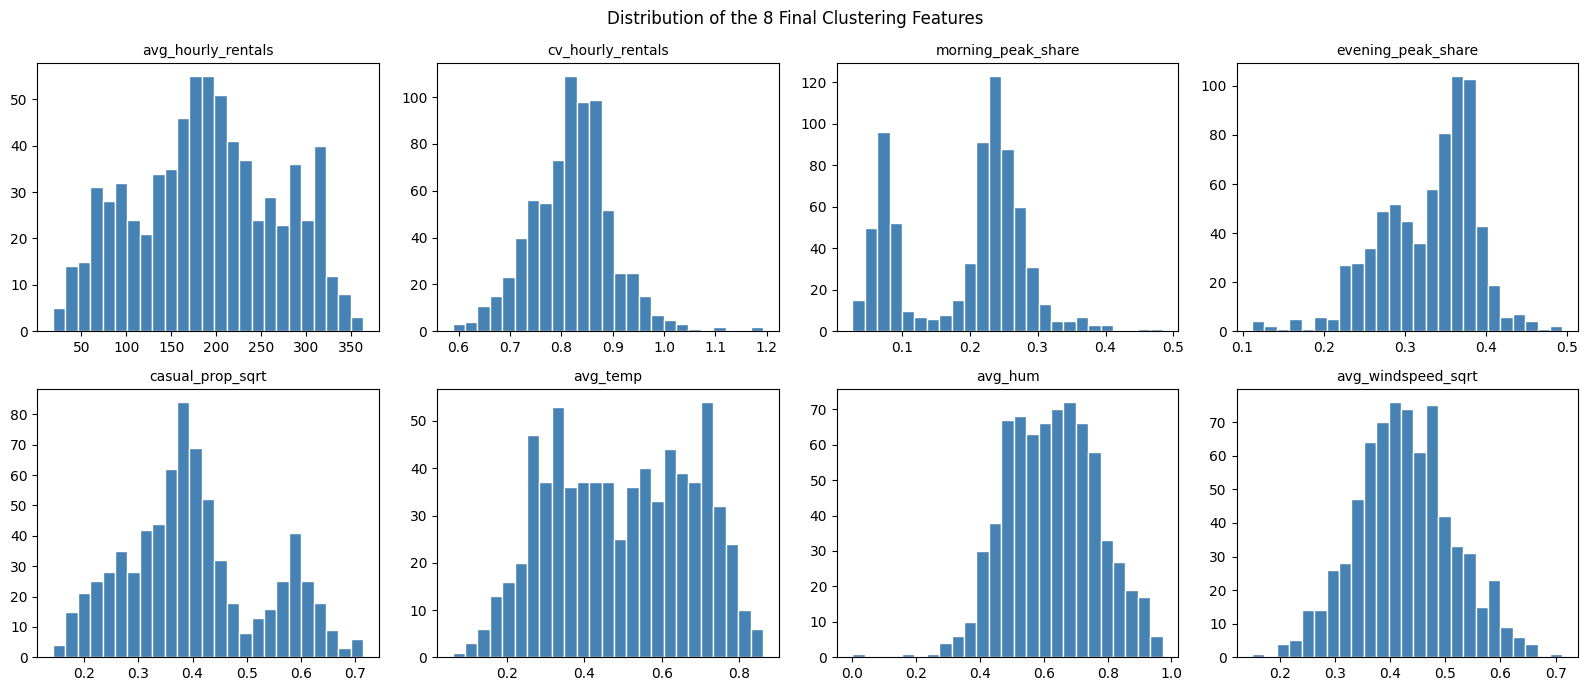

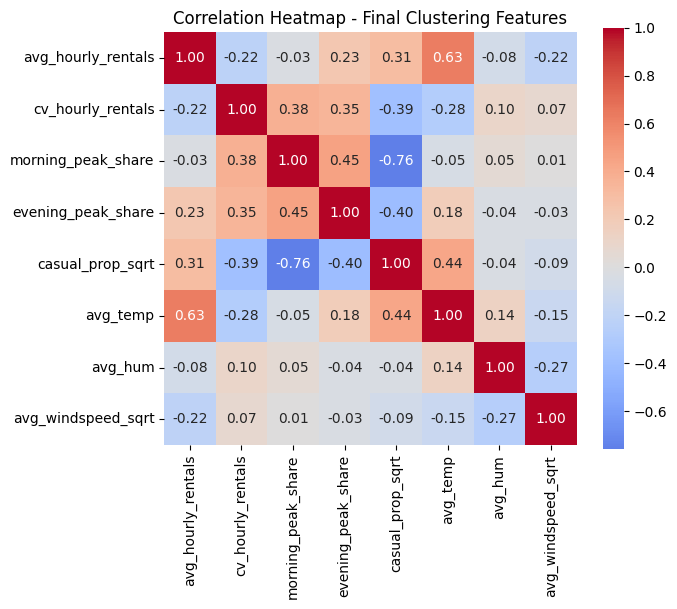

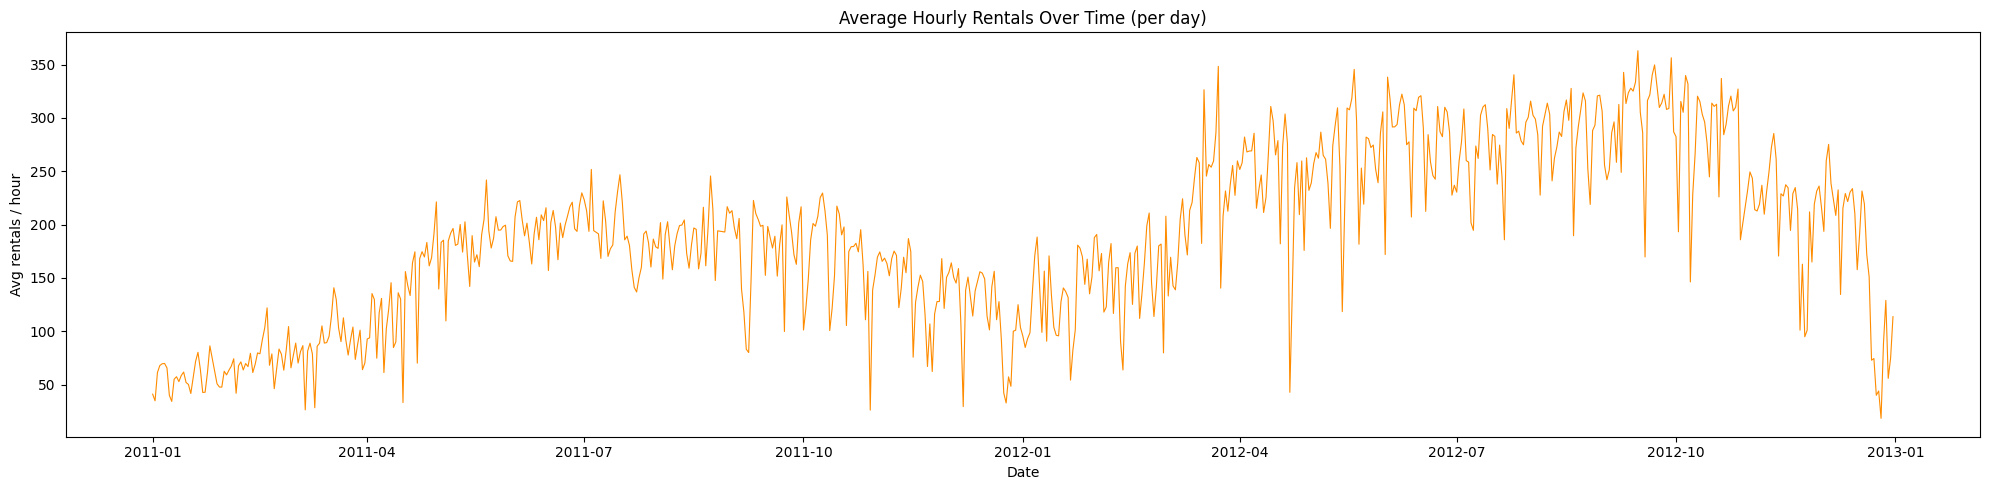

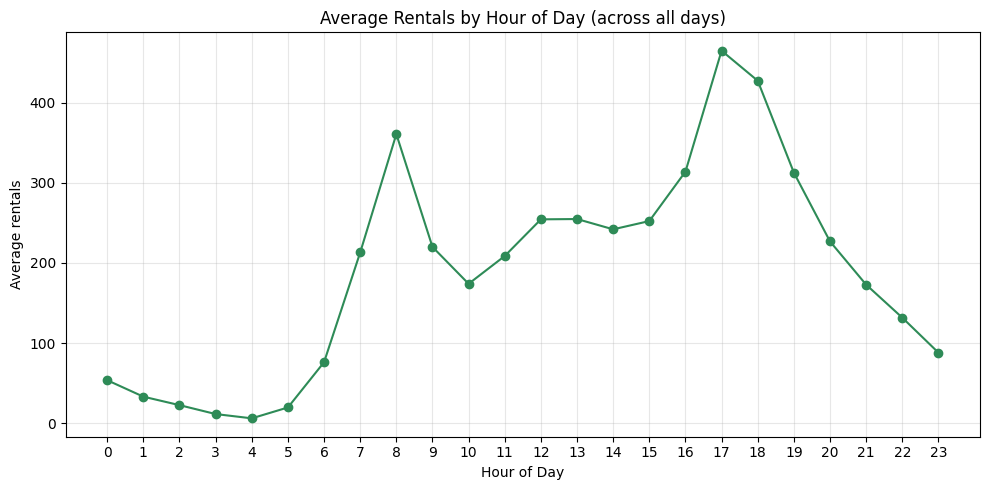

Busiest average hour: 17 with 464.6 avg rentals


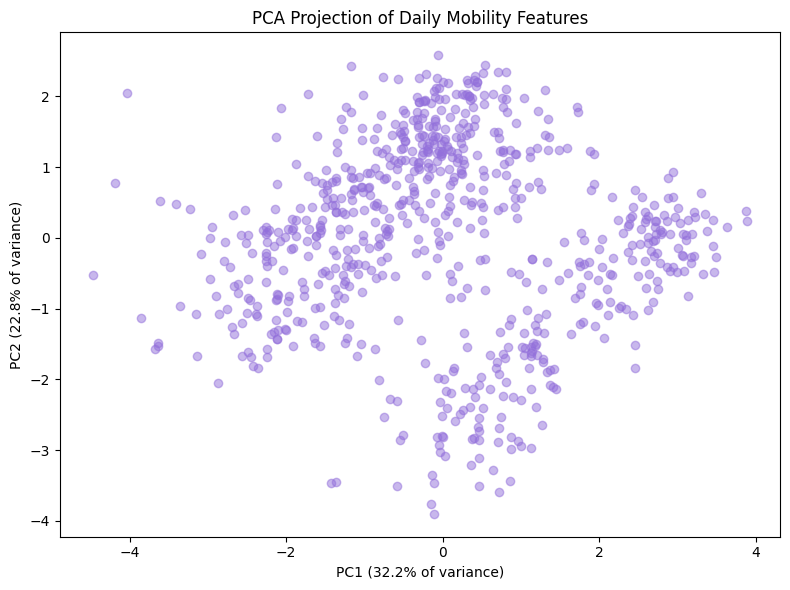

Variance captured by PC1 + PC2: 55.0%


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# 1. Histogram of the final features
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for ax , feature in zip(axes, final_features):
    ax.hist(daily_agg[feature], bins=25, color='steelblue', edgecolor='white')
    ax.set_title(feature, fontsize=10)
plt.suptitle('Distribution of the 8 Final Clustering Features')
plt.tight_layout()
plt.show()

# 2. Correlation heatmap
plt.figure(figsize=(7, 6))
sns.heatmap(daily_agg[final_features].corr(), annot=True, fmt=".2f", 
            cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap - Final Clustering Features')
plt.tight_layout()
plt.show()

# 3. Daily rental pattern plots
# a. How busy the system was, day by day, across the full 2-year span
plt.figure(figsize=(20, 5))
plt.plot(daily_agg['dteday'], daily_agg['avg_hourly_rentals'], color='darkorange', linewidth=0.8)
plt.title('Average Hourly Rentals Over Time (per day)')
plt.xlabel('Date')
plt.ylabel('Avg rentals / hour')
plt.tight_layout()
plt.show()

# b. Average rentals for each hour of the day, averaged across all 723 days.
hourly_profile = df_clean.groupby('hr')['cnt'].mean()
plt.figure(figsize=(10, 5))
plt.plot(hourly_profile.index, hourly_profile.values, marker='o', color='seagreen')
plt.title('Average Rentals by Hour of Day (across all days)')
plt.xlabel('Hour of Day')
plt.ylabel('Average rentals')
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Busiest average hour:", hourly_profile.idxmax(), "with", round(hourly_profile.max(), 1), "avg rentals")

# 4. PCA 2D visualisation
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(pca_coords[:, 0], pca_coords[:, 1], alpha=0.5, color='mediumpurple')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% of variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% of variance)')
plt.title('PCA Projection of Daily Mobility Features')
plt.tight_layout()
plt.show()

print(f"Variance captured by PC1 + PC2: {pca.explained_variance_ratio_.sum()*100:.1f}%")


## Part 2: Apply and Analyse Clustering Methods

### 2.1 K-Means Clustering

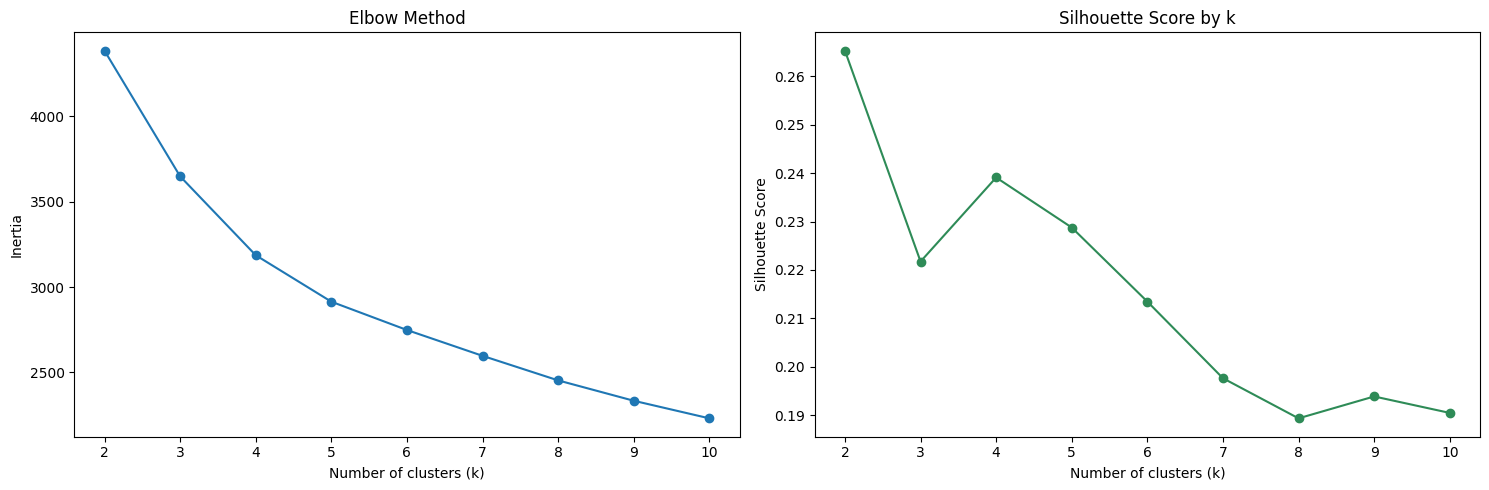

k=2: inertia=4384.6, silhouette=0.2653
k=3: inertia=3648.8, silhouette=0.2217
k=4: inertia=3186.7, silhouette=0.2391
k=5: inertia=2914.5, silhouette=0.2288
k=6: inertia=2748.6, silhouette=0.2135
k=7: inertia=2597.4, silhouette=0.1976
k=8: inertia=2453.5, silhouette=0.1893
k=9: inertia=2334.2, silhouette=0.1939
k=10: inertia=2231.2, silhouette=0.1905

Final cluster sizes:
kmeans_cluster
0    127
1    202
2    283
3    111
Name: count, dtype: int64

Cluster centroids:
kmeans_cluster            0        1        2        3
avg_hourly_rentals  241.132  135.194  236.752  109.363
cv_hourly_rentals     0.744    0.866    0.823    0.821
morning_peak_share    0.084    0.275    0.228    0.078
evening_peak_share    0.277    0.344    0.369    0.258
casual_prop_sqrt      0.587    0.269    0.390    0.459
avg_temp              0.628    0.335    0.628    0.308
avg_hum               0.638    0.627    0.632    0.598
avg_windspeed_sqrt    0.406    0.443    0.415    0.450


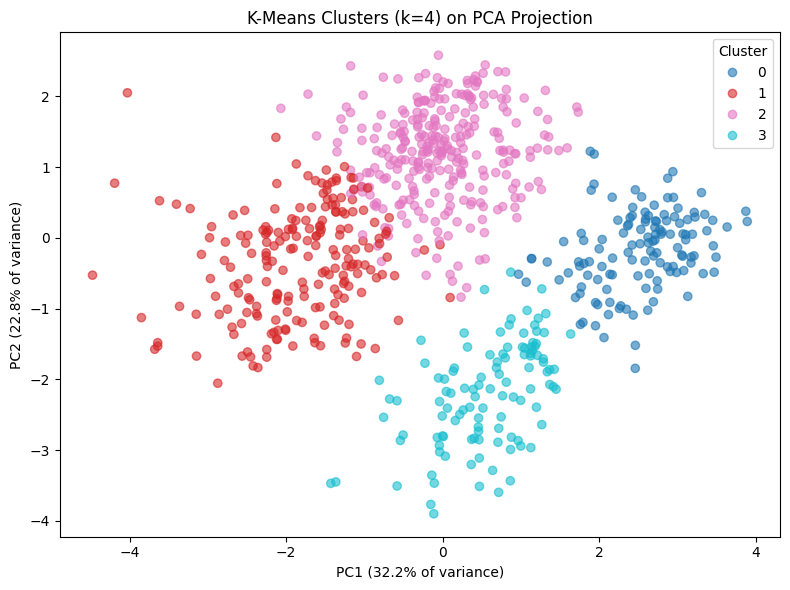

In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Find suitable number of clusters
inertias = []
sil_scores = []
K_range = range(2,11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

# Plot the Elbow Method
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(list(K_range), inertias, marker='o')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

# Plot the Silhouette Score
axes[1].plot(list(K_range), sil_scores, marker='o', color='seagreen')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by k')
plt.tight_layout()
plt.show()

for k, inertia, sil in zip(K_range, inertias, sil_scores):
    print(f"k={k}: inertia={inertia:.1f}, silhouette={sil:.4f}")

# Choose the final k
FINAL_K = 4
kmeans_final = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
daily_agg['kmeans_cluster'] = kmeans_final.fit_predict(X_scaled)

print("\nFinal cluster sizes:")
print(daily_agg['kmeans_cluster'].value_counts().sort_index())

# Report centroids in the original feature scale
centroids_original_scale = daily_agg.groupby('kmeans_cluster')[final_features].mean().round(3)
print("\nCluster centroids:")
print(centroids_original_scale.T)

# Visualise the clusters using PCA
plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_coords[:, 0], pca_coords[:, 1],
                       c=daily_agg['kmeans_cluster'], cmap='tab10', alpha=0.6)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% of variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% of variance)')
plt.title(f'K-Means Clusters (k={FINAL_K}) on PCA Projection')
plt.legend(*scatter.legend_elements(), title='Cluster')
plt.tight_layout()
plt.show()



**Preliminary interpretation of the k=4 K-Means clusters**

- **Cluster 0** (n=127): High volume (avg ≈241 rentals/hr), very low morning-peak share, warm average temperature, highest casual-user share → likely warm-season, leisure-dominated high-demand days.
- **Cluster 1** (n=202): Lower volume (≈135/hr), highest morning- and evening-peak shares combined, coldest average temperature, lowest casual-user share → likely cold-season, commuter-dominated days.
- **Cluster 2** (n=283): High volume (≈237/hr), moderate-to-high peak shares, warm average temperature → likely warm-season commuter/workday days. It is the largest cluster.
- **Cluster 3** (n=111): Lowest volume (≈109/hr), low peak shares, coldest average temperature → likely cold-season, low-demand quiet days.

This groups days along two main axes that emerged from the centroids: **season/temperature** and **commuter-timing intensity**.

### 2.2 Hierarchical Clustering (AGNES)

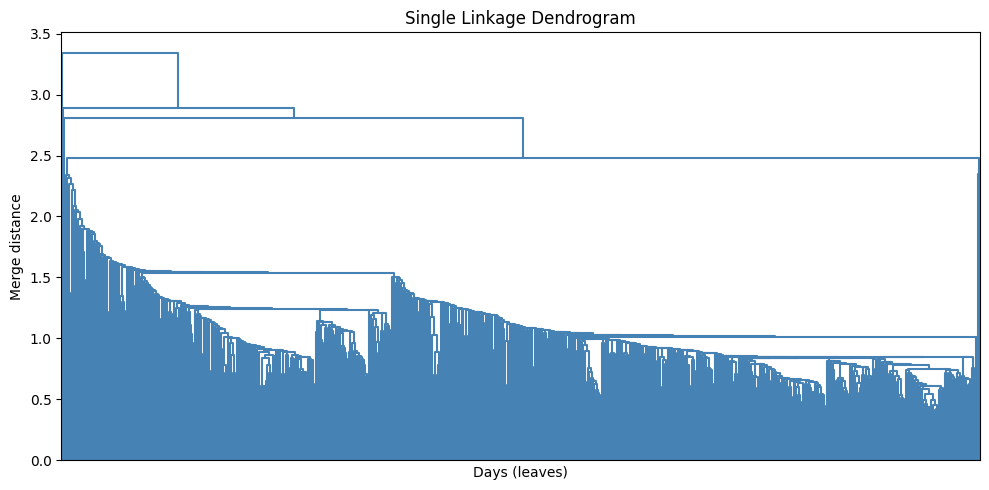

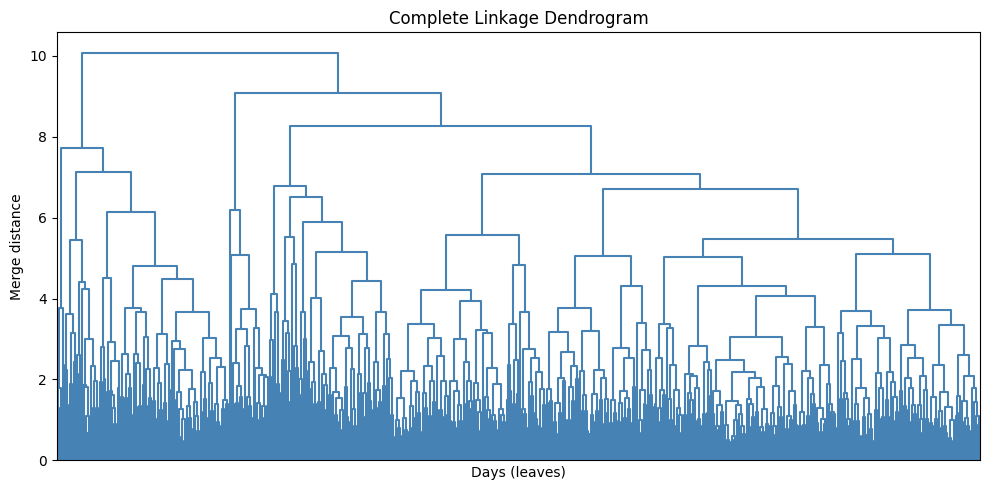

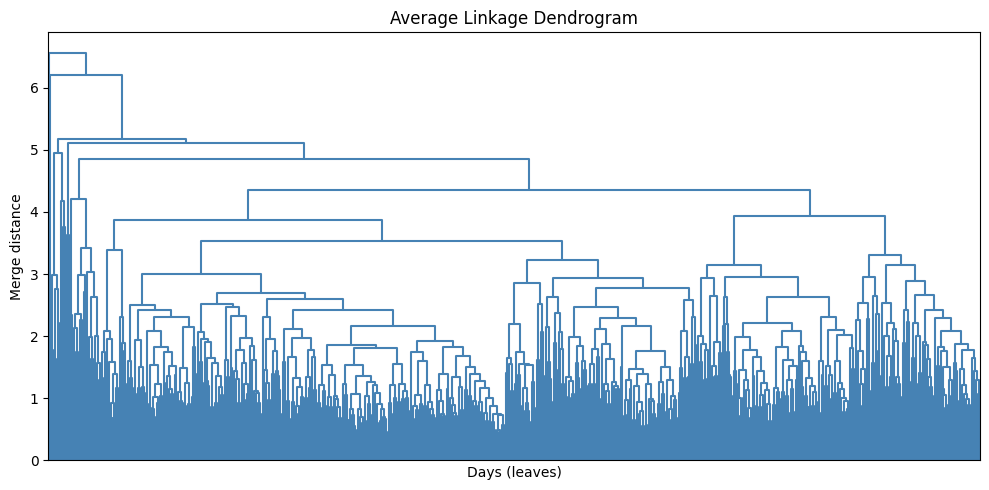

  method  k  silhouette                     cluster_sizes  largest_cluster_pct
  single  2      0.3878                          [722, 1]                 99.9
  single  3      0.3273                       [721, 1, 1]                 99.7
  single  4      0.2797                    [720, 1, 1, 1]                 99.6
  single  5      0.2791                 [718, 2, 1, 1, 1]                 99.3
  single  6      0.2755              [718, 1, 1, 1, 1, 1]                 99.3
  single  7      0.2386           [717, 1, 1, 1, 1, 1, 1]                 99.2
  single  8      0.1846        [716, 1, 1, 1, 1, 1, 1, 1]                 99.0
complete  2      0.1594                        [588, 135]                 81.3
complete  3      0.1138                    [557, 135, 31]                 77.0
complete  4      0.1374                [459, 135, 98, 31]                 63.5
complete  5      0.1295             [459, 129, 98, 31, 6]                 63.5
complete  6      0.1167         [459, 102, 98, 31, 2

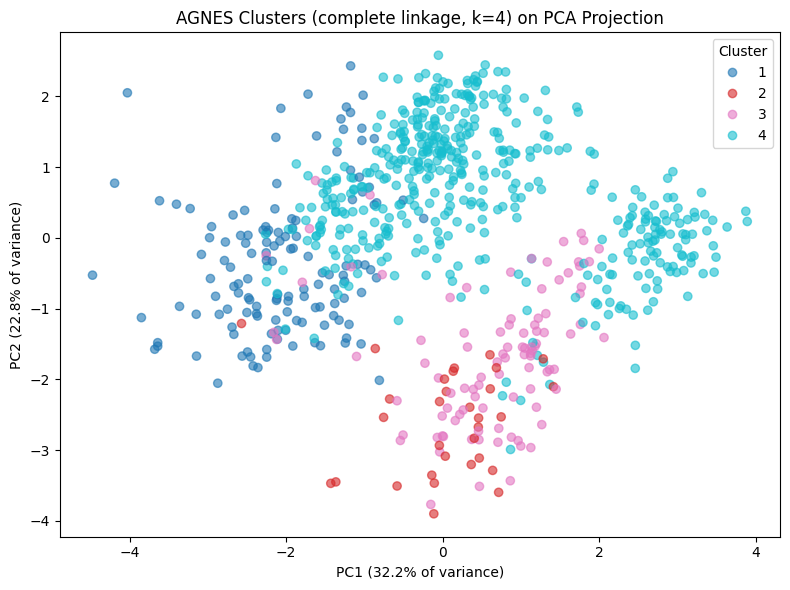

In [7]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Build the linkage matrix for each of the 3 linkage methods
linkage_methods = ['single', 'complete', 'average']
linkage_matrices = {method: linkage(X_scaled, method=method) for method in linkage_methods}

# Plot a dendrogram for each method
for method in linkage_methods:
    plt.figure(figsize=(10, 5))
    dendrogram(linkage_matrices[method], no_labels=True,
               color_threshold=0, above_threshold_color='steelblue')
    plt.title(f'{method.capitalize()} Linkage Dendrogram')
    plt.xlabel('Days (leaves)')
    plt.ylabel('Merge distance')
    plt.tight_layout()
    plt.show()

# Identify the suitable cluster
results = []
for method in linkage_methods:
    Z = linkage_matrices[method]
    for k in range(2, 9):
        labels = fcluster(Z, t=k, criterion='maxclust')
        if len(set(labels)) < 2:
            continue
        sil = silhouette_score(X_scaled, labels)
        sizes = sorted(pd.Series(labels).value_counts().tolist(), reverse=True)
        results.append({'method': method, 'k': k, 'silhouette': round(sil, 4),
                         'cluster_sizes': sizes, 'largest_cluster_pct': round(max(sizes)/len(labels)*100, 1)})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

print("\nLargest-cluster share of the data, by method:")
print(results_df.groupby('method')['largest_cluster_pct'].mean().round(1))

# Final decision
FINAL_METHOD = 'complete'
FINAL_K_AGNES = 4

daily_agg['agnes_cluster'] = fcluster(linkage_matrices[FINAL_METHOD], t=FINAL_K_AGNES, criterion='maxclust')
print(f"\nFinal AGNES ({FINAL_METHOD} linkage, k={FINAL_K_AGNES}) cluster sizes:")
print(daily_agg['agnes_cluster'].value_counts().sort_index())

# Visualise the AGNES clusters on the PCA 
plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_coords[:, 0], pca_coords[:, 1],
                       c=daily_agg['agnes_cluster'], cmap='tab10', alpha=0.6)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% of variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% of variance)')
plt.title(f'AGNES Clusters ({FINAL_METHOD} linkage, k={FINAL_K_AGNES}) on PCA Projection')
plt.legend(*scatter.legend_elements(), title='Cluster')
plt.tight_layout()
plt.show()



### Differences Between the Cluster Structures

The three linkage methods produced structurally different results on the same data:

- **Single linkage** merged the data into one dominant cluster almost immediately,
  with the largest cluster holding **99.0–99.9%** of all 723 days across every
  k tested (2 through 8). The remaining "clusters" were single isolated days.
- **Average linkage** showed the same pattern, only slightly less extreme:
  its largest cluster held **93.0% of days on average** across all k, still
  dominated by one giant group plus a handful of outliers removed off one at a time.
- **Complete linkage** produced the most balanced structure by far: its largest
  cluster held **63.3% of days on average**, steadily shrinking from 81.3% at
  k=2 down to 47.0% at k=7-8 as more clusters were introduced - indicating it
  was genuinely partitioning the data rather than isolating outliers.

This pattern is consistent with single and average linkage's known vulnerability
to the **chaining effect**. Complete linkage's use of the farthest-pair distance between clusters actively resists this, which is reflected directly in its far more balanced cluster sizes.

### Supporting the Final Clustering Decision

The final clustering (**complete linkage, k=4**) was selected using evaluation
results rather than by visually inspecting the dendrograms:

- Single and average linkage achieved *higher* silhouette scores at k=2 (0.388 and 0.403 respectively) than complete linkage (0.159 at best). However, both isolates single outlier days as their own "cluster" - their near-100% largest-cluster share confirms this is a degenerate split, not a meaningful one.
- Complete linkage's silhouette score at k=4 (0.137) is only modestly lower than its own best score at k=2 (0.159), while its cluster-size balance (135 / 98 / 459 / 31) remains reasonable at k=4, unlike single and average linkage at any k.
- Cross-checked against earlier result in 2.1, k=4 also matches the K-Means result, allowing a direct, like-for-like comparison of both methods' cluster structures.

### 2.3 DBSCAN

Testing min_samples=16 (2 x n_features) across a range of eps:
  eps=1.4: clusters=3, noise=229 (31.7%)
  eps=1.6: clusters=2, noise=141 (19.5%)
  eps=1.8: clusters=1, noise=64 (8.9%)
  eps=2.0: clusters=1, noise=40 (5.5%)
  eps=2.2: clusters=1, noise=19 (2.6%)
  eps=2.4: clusters=1, noise=11 (1.5%)
  eps=2.6: clusters=1, noise=8 (1.1%)

Testing min_samples=10 (just above n_features + 1) across a range of eps:
  eps=1.4: clusters=2, noise=184 (25.4%)
  eps=1.6: clusters=2, noise=96 (13.3%)
  eps=1.8: clusters=1, noise=46 (6.4%)
  eps=2.0: clusters=1, noise=32 (4.4%)
  eps=2.2: clusters=1, noise=15 (2.1%)
  eps=2.4: clusters=1, noise=11 (1.5%)
  eps=2.6: clusters=1, noise=6 (0.8%)


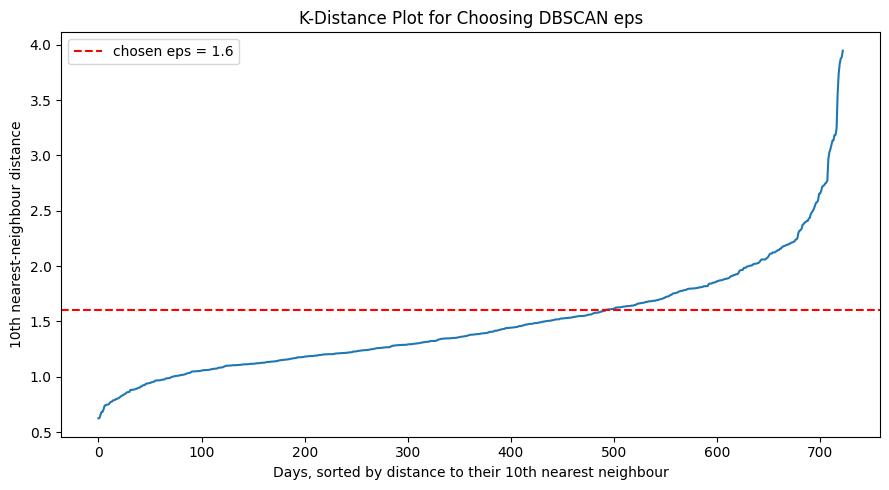

DBSCAN (eps=1.6, min_samples=10): 2 clusters, 96 noise points (13.3% of all days)

Cluster sizes :
dbscan_cluster
-1     96
 0    442
 1    185
Name: count, dtype: int64
eps=1.4, min_samples=10 (tighter eps, same min_samples): 2 clusters, 184 noise points (25.4%)
eps=1.6, min_samples=16 (same eps, stricter min_samples): 2 clusters, 141 noise points (19.5%)


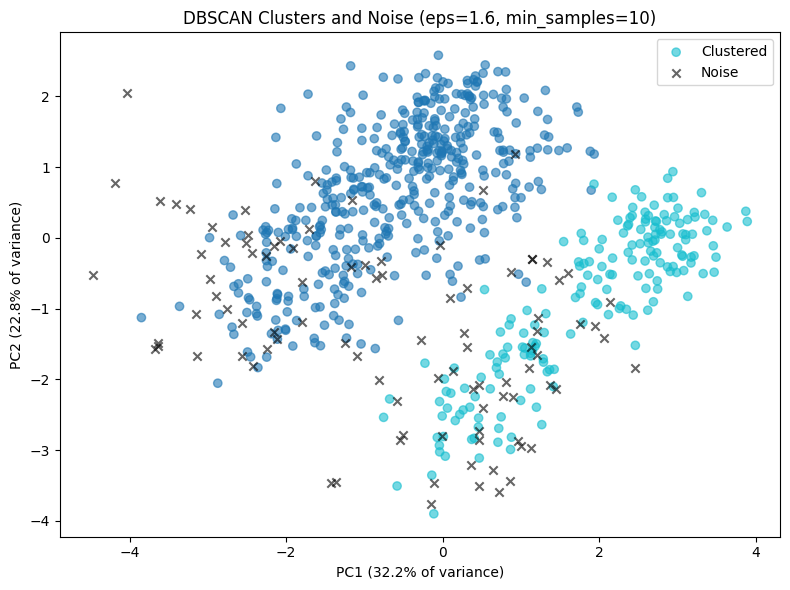


Noise-day average windspeed: 0.232  vs. all-day average: 0.19
Noise-day holiday rate: 5.2 %  vs. all-day holiday rate: 2.9 %


In [8]:
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

# Choose min_samples
print("Testing min_samples=16 (2 x n_features) across a range of eps:")
for eps_test in [1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6]:
    db_test = DBSCAN(eps=eps_test, min_samples=16).fit(X_scaled)
    labels_test = db_test.labels_
    k_test = len(set(labels_test)) - (1 if -1 in labels_test else 0) # collect distinct values except -1
    noise_test = list(labels_test).count(-1) # -1 = noise
    print(f"  eps={eps_test}: clusters={k_test}, noise={noise_test} ({noise_test/len(daily_agg)*100:.1f}%)")

print("\nTesting min_samples=10 (just above n_features + 1) across a range of eps:")
for eps_test in [1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6]:
    db_test = DBSCAN(eps=eps_test, min_samples=10).fit(X_scaled)
    labels_test = db_test.labels_
    k_test = len(set(labels_test)) - (1 if -1 in labels_test else 0)
    noise_test = list(labels_test).count(-1)
    print(f"  eps={eps_test}: clusters={k_test}, noise={noise_test} ({noise_test/len(daily_agg)*100:.1f}%)")

MIN_SAMPLES = 10

# Nearest-neighbour (k-distance) plot to choose eps
neighbors = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(9, 5))
plt.plot(k_distances)
plt.axhline(y=1.6, color='red', linestyle='--', label='chosen eps = 1.6')
plt.xlabel(f'Days, sorted by distance to their {MIN_SAMPLES}th nearest neighbour')
plt.ylabel(f'{MIN_SAMPLES}th nearest-neighbour distance')
plt.title('K-Distance Plot for Choosing DBSCAN eps')
plt.legend()
plt.tight_layout()
plt.show()

EPS = 1.6

# Fit DBSCAN with the chosen parameters
dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
daily_agg['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

n_clusters = len(set(daily_agg['dbscan_cluster'])) - (1 if -1 in daily_agg['dbscan_cluster'].values else 0)
n_noise = (daily_agg['dbscan_cluster'] == -1).sum()
print(f"DBSCAN (eps={EPS}, min_samples={MIN_SAMPLES}): {n_clusters} clusters, {n_noise} noise points "
      f"({n_noise/len(daily_agg)*100:.1f}% of all days)")
print("\nCluster sizes :")
print(daily_agg['dbscan_cluster'].value_counts().sort_index())

# Sensitivity to alternative parameter settings
for eps_alt, min_samp_alt, note in [
    (1.4, 10, "tighter eps, same min_samples"),
    (1.6, 16, "same eps, stricter min_samples"),
]:
    db_alt = DBSCAN(eps=eps_alt, min_samples=min_samp_alt).fit(X_scaled)
    labels_alt = db_alt.labels_
    k_alt = len(set(labels_alt)) - (1 if -1 in labels_alt else 0)
    noise_alt = list(labels_alt).count(-1)
    print(f"eps={eps_alt}, min_samples={min_samp_alt} ({note}): "
          f"{k_alt} clusters, {noise_alt} noise points ({noise_alt/len(daily_agg)*100:.1f}%)")

# Visualise clusters and noise on the PCA
plt.figure(figsize=(8, 6))
is_noise = daily_agg['dbscan_cluster'] == -1
plt.scatter(pca_coords[~is_noise, 0], pca_coords[~is_noise, 1],
            c=daily_agg.loc[~is_noise, 'dbscan_cluster'], cmap='tab10', alpha=0.6, label='Clustered')
plt.scatter(pca_coords[is_noise, 0], pca_coords[is_noise, 1],
            c='black', marker='x', alpha=0.6, label='Noise')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% of variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% of variance)')
plt.title(f'DBSCAN Clusters and Noise (eps={EPS}, min_samples={MIN_SAMPLES})')
plt.legend()
plt.tight_layout()
plt.show()

# Check if the noise points data errors or real unusual days
noise_days = daily_agg[daily_agg['dbscan_cluster'] == -1]
print("\nNoise-day average windspeed:", round(noise_days['avg_windspeed'].mean(), 3),
      " vs. all-day average:", round(daily_agg['avg_windspeed'].mean(), 3))
print("Noise-day holiday rate:", round(noise_days['holiday'].mean()*100, 1), "%",
      " vs. all-day holiday rate:", round(daily_agg['holiday'].mean()*100, 1), "%")


### Justification of the Selected min_samples Value

A common heuristic for DBSCAN in higher-dimensional data is `min_samples ≥ n_features + 1`,mwhich for this 8-feature clustering set gives a minimum of 9. A more conservative alternative sometimes used is double the feature count (`2 × 8 = 16`).

- **min_samples = 16** produced a genuine 2-cluster structure at only a single point
  in the tested range (eps = 1.6), collapsing to one cluster almost everywhere else.
  Even at its best point, it flagged 141 days (19.5%) as noise.
- **min_samples = 10** produced the same 2-cluster structure across two adjacent
  eps values (1.4 and 1.6) - a wider, more stable window - and at the shared
  eps = 1.6, flagged far fewer days as noise (96, 13.3%) for an equivalent
  cluster structure.

**min_samples = 10** was therefore selected: it sits just above the standard
`n_features + 1` heuristic, produces a more stable 2-cluster result across a
wider parameter range, and retains more days as meaningfully clustered rather
than discarding them as noise, compared to the more conservative `2 × n_features`
alternative.

## Part 3: Clustering Evaluation and Comparison

In [10]:
from sklearn.metrics import davies_bouldin_score
from scipy.spatial.distance import pdist

# Compute Silhouette, Davies-Bouldin, and intra/inter-cluster distance
def evaluate_clustering(labels, name, exclude_noise=False):
    labels = np.array(labels)

    # For DBSCAN, noise points (label -1) are excluded from the calculation 
    # as metrics like silhouette and Davies-Bouldin are undefined for a "noise" label, since it is not a real cluster
    if exclude_noise:
        mask = labels != -1
        X_eval, labels_eval = X_scaled[mask], labels[mask]
        n_excluded = (~mask).sum() # Flip noise to True and count them
    else: # For KMeans and AGNES
        X_eval, labels_eval = X_scaled, labels
        n_excluded = 0

    sil = silhouette_score(X_eval, labels_eval)
    dbi = davies_bouldin_score(X_eval, labels_eval)

    # Compute each cluster's centroid
    centroids = []
    unique_labels = sorted(set(labels_eval))
    for cluster in unique_labels:
        points = X_eval[labels_eval == cluster]
        centroid = points.mean(axis=0)
        centroids.append(centroid)
    centroids = np.array(centroids)

    # Compute intra-cluster distance
    intra_distances = []
    for i, cluster in enumerate(unique_labels):
        points = X_eval[labels_eval == cluster]
        distances_to_centroid = np.linalg.norm(points - centroids[i], axis=1) 
        avg_distance = distances_to_centroid.mean()     
        intra_distances.append(avg_distance)
    intra = np.mean(intra_distances)

    # Compute inter-cluster distance
    inter = np.mean(pdist(centroids))
    sizes = pd.Series(labels_eval).value_counts().sort_index().tolist()

    print(f"{name}")
    if n_excluded:
        print(f"  ({n_excluded} noise points excluded, "
              f"{n_excluded/len(labels)*100:.1f}% of all days)")
    print(f"  Silhouette Score:            {sil:.4f}")
    print(f"  Davies-Bouldin Index:        {dbi:.4f}")
    print(f"  Avg intra-cluster distance:  {intra:.4f}")
    print(f"  Avg inter-centroid distance: {inter:.4f}")
    print(f"  Cluster sizes:               {sizes}\n")

    return {'method': name, 'silhouette': round(sil, 4), 'davies_bouldin': round(dbi, 4),
            'intra_dist': round(intra, 4), 'inter_dist': round(inter, 4), 'sizes': sizes}

eval_results = []
eval_results.append(evaluate_clustering(daily_agg['kmeans_cluster'], 'K-Means (k=4)'))
eval_results.append(evaluate_clustering(daily_agg['agnes_cluster'], 'AGNES (complete linkage, k=4)'))
eval_results.append(evaluate_clustering(daily_agg['dbscan_cluster'], 'DBSCAN (eps=1.6, min_samples=10)', exclude_noise=True))
eval_df = pd.DataFrame(eval_results)

print(eval_df[['method', 'silhouette', 'davies_bouldin', 'intra_dist', 'inter_dist']].to_string(index=False))


K-Means (k=4)
  Silhouette Score:            0.2391
  Davies-Bouldin Index:        1.5101
  Avg intra-cluster distance:  2.0007
  Avg inter-centroid distance: 3.2213
  Cluster sizes:               [127, 202, 283, 111]

AGNES (complete linkage, k=4)
  Silhouette Score:            0.1374
  Davies-Bouldin Index:        1.7411
  Avg intra-cluster distance:  2.2043
  Avg inter-centroid distance: 2.9713
  Cluster sizes:               [135, 31, 98, 459]

DBSCAN (eps=1.6, min_samples=10)
  (96 noise points excluded, 13.3% of all days)
  Silhouette Score:            0.2970
  Davies-Bouldin Index:        1.4500
  Avg intra-cluster distance:  2.1569
  Avg inter-centroid distance: 2.9752
  Cluster sizes:               [442, 185]

                          method  silhouette  davies_bouldin  intra_dist  inter_dist
                   K-Means (k=4)      0.2391          1.5101      2.0007      3.2213
   AGNES (complete linkage, k=4)      0.1374          1.7411      2.2043      2.9713
DBSCAN (eps=1.6, 

### Comparing the Three Clustering Methods

| Criterion | K-Means (k=4) | AGNES complete (k=4) | DBSCAN (2 clusters + noise) |
|---|---|---|---|
| Silhouette Score | 0.239 | 0.137 | **0.297** (on 87% of days) |
| Davies-Bouldin Index | 1.510 | 1.741 | **1.450** (on 87% of days) |
| Cluster separation (inter-centroid dist.) | **3.221** | 2.971 | 2.975 |
| Cluster compactness (intra-cluster dist.) | **2.001** | 2.204 | 2.157 |
| Cluster size balance | 127/202/283/111 (balanced) | 135/31/98/459 (one dominant cluster) | 442/185 (uneven, plus 96 unassigned) |
| Sensitivity to parameters | Low (elbow/silhouette stable across k) | Moderate (linkage choice changes structure entirely) | High (small eps/min_samples changes shift noise % substantially) |
| Interpretability | High - 4 distinct, balanced, real-world-mappable groups | Moderate - one cluster dominates, diluting distinctiveness | Moderate - only 2 broad categories, 13.3% of days left unclassified |
| Treatment of unusual days | Forces every day into a cluster (no explicit outlier handling) | Forces every day into a cluster | Explicitly separates unusual days as noise |

**DBSCAN's noise handling:** all DBSCAN metrics above exclude its 96 noise days
(13.3%) - Silhouette and Davies-Bouldin are undefined for a "noise" label.
This means DBSCAN is scored on an easier 87% subset, while K-Means and AGNES
are scored on all 723 days. Its leading scores are therefore not a fair
like-for-like comparison, and not sufficient alone to call it the best method.

**Final selection: K-Means (k=4)** is the most suitable result. DBSCAN's better
scores reflect an easier subset, not genuine superiority. K-Means gives the
best separation/compactness among methods evaluated on the full dataset, four
balanced clusters (vs. AGNES's dominant 459-day cluster), classifies every day
with no days discarded, and its parameter choice was the most stable across
sensitivity checks

## Part 4: Cluster Interpretation and Validation

In [19]:
# Original, non-standardized features used for the cluster's profile
profile_cols = ['total_rentals', 'avg_hourly_rentals', 'morning_peak_share',
                 'evening_peak_share', 'casual_prop', 'avg_temp', 'avg_hum', 'avg_windspeed']
print("Cluster profiles:")
print(daily_agg.groupby('kmeans_cluster')[profile_cols].mean().round(3).T)

# Compare weekday / weekend / holiday / season / weather across clusters
daily_agg['is_weekend'] = daily_agg['weekday'].isin([0, 6]) 
print("\nWeekend share by cluster:")
print(daily_agg.groupby('kmeans_cluster')['is_weekend'].mean().round(3))

print("\nHoliday rate by cluster:")
print(daily_agg.groupby('kmeans_cluster')['holiday'].mean().round(3))

print("\nWorking-day rate by cluster:")
print(daily_agg.groupby('kmeans_cluster')['workingday'].mean().round(3))

print("\nSeason distribution by cluster (1=spring, 2=summer, 3=fall, 4=winter):")
print(pd.crosstab(daily_agg['kmeans_cluster'], daily_agg['season'], normalize='index').round(2))

print("\nWeather-situation distribution by cluster (1=clear, 2=mist, 3=light precip):")
print(pd.crosstab(daily_agg['kmeans_cluster'], daily_agg['weathersit'], normalize='index').round(2))




Cluster profiles:
kmeans_cluster             0         1         2         3
total_rentals       5786.047  3222.010  5679.530  2613.162
avg_hourly_rentals   241.132   135.194   236.752   109.363
morning_peak_share     0.084     0.275     0.228     0.078
evening_peak_share     0.277     0.344     0.369     0.258
casual_prop            0.347     0.076     0.153     0.223
avg_temp               0.628     0.335     0.628     0.308
avg_hum                0.638     0.627     0.632     0.598
avg_windspeed          0.170     0.206     0.178     0.212

Weekend share by cluster:
kmeans_cluster
0    0.898
1    0.000
2    0.000
3    0.847
Name: is_weekend, dtype: float64

Holiday rate by cluster:
kmeans_cluster
0    0.055
1    0.000
2    0.014
3    0.090
Name: holiday, dtype: float64

Working-day rate by cluster:
kmeans_cluster
0    0.047
1    1.000
2    0.986
3    0.063
Name: workingday, dtype: float64

Season distribution by cluster (1=spring, 2=summer, 3=fall, 4=winter):
season             1   

### Cluster Names, Behaviour, and Practical Insights

The weekday/season/holiday breakdown reveals a clean structure: the 4 clusters
split almost perfectly along two axes - **weekday vs. weekend** and
**warm vs. cold season** - which is a strong, real-world-grounded validation of
the K-Means grouping.

| Cluster | n | Name | Weekend share | Working-day rate | Avg temp | Avg rentals/hr | Casual share |
|---|---|---|---|---|---|---|---|
| 2 | 283 | **Warm-Season Weekday Commuters** | 0% | 98.6% | 0.63 (warm) | 236.8 (high) | 15.3% |
| 1 | 202 | **Cold-Season Weekday Commuters** | 0% | 100% | 0.34 (cold) | 135.2 | 7.6% (lowest) |
| 0 | 127 | **Warm-Season Weekend/Leisure Days** | 89.8% | 4.7% | 0.63 (warm) | 241.1 (highest) | 34.7% (highest) |
| 3 | 111 | **Cold-Season Weekend/Holiday Days** | 84.7% | 6.3% | 0.31 (coldest) | 109.4 (lowest) | 22.3% |

- **Cluster 2 - Warm-Season Weekday Commuters** (the largest group, 39.1% of all
  days): near-100% working days, strong morning (0.23) and the highest evening
  (0.37) peak shares, warm weather, high volume. The dominant "typical day" for
  the system.
- **Cluster 1 - Cold-Season Weekday Commuters**: same working-day/peak-timing
  pattern as Cluster 2, but volume drops by ~43% (135 vs. 237 rentals/hr) and
  casual ridership nearly disappears (7.6% vs. 15.3%) - commuting continues
  through winter, just at reduced scale, almost entirely by registered riders.
- **Cluster 0 - Warm-Season Weekend/Leisure Days**: 89.8% weekend, highest
  overall volume (241/hr) and by far the highest casual-rider share (34.7%) -
  warm weekends draw the heaviest recreational use of the whole system.
- **Cluster 3 - Cold-Season Weekend/Holiday Days**: lowest volume by a wide
  margin (109/hr), highest holiday rate (9.0%) of any cluster - the system's
  quietest, lowest-stakes period.


**Practical insights for planning:**

1. **Seasonal fleet and maintenance scheduling.** Weekday commuter volume drops
   ~43% in winter (Cluster 1 vs. 2) despite the same commute pattern - a
   data-backed window for a smaller deployed fleet and freed-up maintenance time.
2. **Casual-rider-focused rebalancing.** Casual ridership concentrates in warm
   weekends (34.7% share, over double any other cluster) - rebalancing should
   target recreational stations before warm weekends and commuter stations
   before weekdays, rather than one system-wide strategy.
3. **Lowest-disruption maintenance window.** Cluster 3 (cold weekends/holidays)
   has the lowest volume and highest holiday concentration of any cluster -
   the clearest window for larger maintenance or station relocation work.

## Part 5: Theoretical Understanding
Written answers to the 10 theory questions — drafted together with the report in Step 10.